In [83]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [84]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

In [87]:
query = """
SELECT 
    CASE
        WHEN CAST(strftime('%w', timestamp) AS INTEGER) BETWEEN 1 AND 5 THEN 'working_day'
        ELSE 'weekend'
    END AS day,
    strftime('%H', timestamp) AS hour,
    COUNT(*) as commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY
    CASE
        WHEN CAST(strftime('%w', timestamp) AS INTEGER) BETWEEN 1 AND 5 THEN 'working_day'
        ELSE 'weekend'
    END,
    strftime('%H', timestamp);
"""


commits_df = pd.read_sql(query, conn)
commits_df

,day,hour,commits
0,weekend,00,6
1,weekend,01,6
2,weekend,03,1
3,weekend,05,2
4,weekend,07,16
5,weekend,08,28
6,weekend,09,22
7,weekend,10,28
8,weekend,11,118
9,weekend,12,57


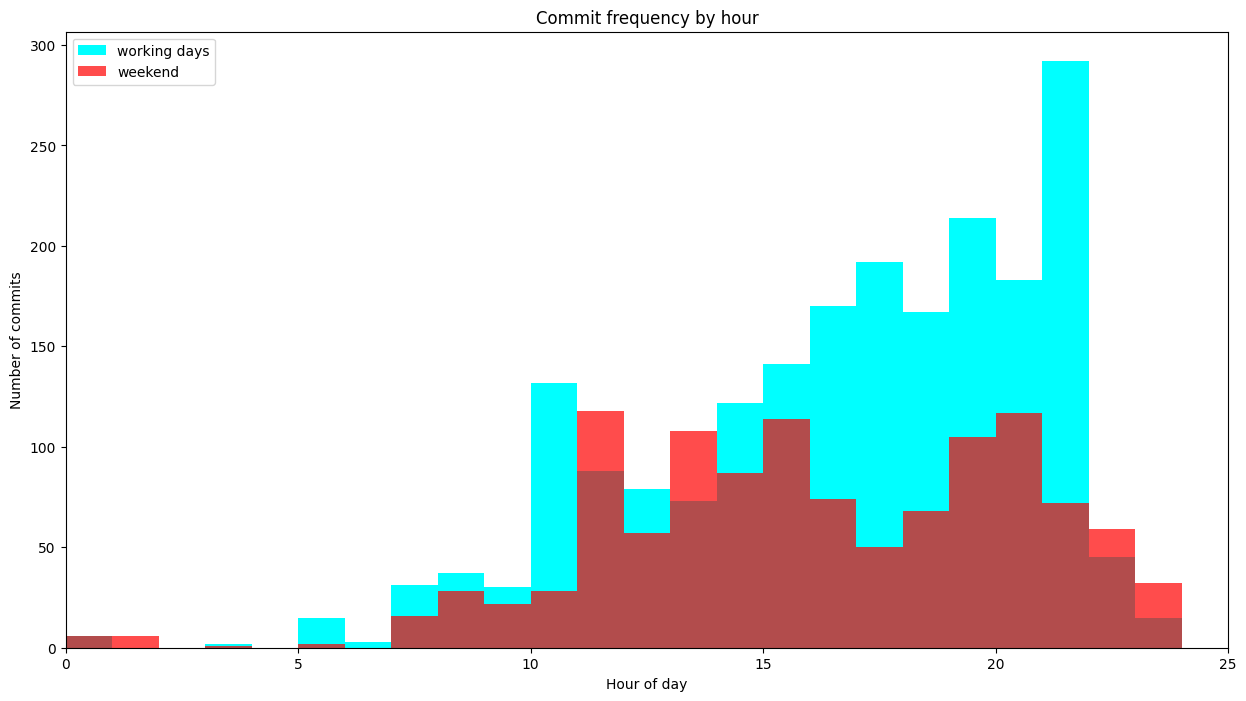

In [101]:
weekend = commits_df[commits_df['day'] == 'weekend']
working = commits_df[commits_df['day'] == 'working_day']

plt.figure(figsize=(15, 8))

plt.hist(working['hour'].astype(int), bins=range(25), 
         weights=working['commits'], label='working days', color='cyan')

plt.hist(weekend['hour'].astype(int), bins=range(25), 
         weights=weekend['commits'], alpha=0.7, label='weekend', color='red')

plt.xlim(0, 25)
plt.ylim(bottom=0)
plt.xlabel('Hour of day')
plt.ylabel('Number of commits')
plt.title('Commit frequency by hour')
plt.legend()
plt.show()

In [100]:
conn.close()

Are there hours when the total number of commits was higher on weekends than on working days?

11, 13, 22, 23